# Benchmark Comparison: Global vs Local

In [21]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SINGLE_COL = (3.5, 2.5)
DOUBLE_COL = (6.5, 3.5)

mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False,
    "pgf.preamble": r"\usepackage{amsfonts}\usepackage{amssymb}\usepackage{amsmath}",
    "lines.linewidth": 1,
    "figure.figsize": SINGLE_COL,
    "font.size": 9,
    "savefig.dpi": 300,
})

In [22]:
# --- Load benchmark summary ---
summary_path = Path("/home/dw/canari/experiments/out/experiment_lstm_LGA008EFAPRG910_benchmark_summary.json")

with open(summary_path) as f:
    summary = json.load(f)

df = pd.DataFrame(summary["runs"])
df["delay_days"] = pd.to_timedelta(df["delay"]).dt.days
df

,condition,seed,false_alarm_rate,false_alarm_count,num_pre_anomaly,detected,delay_steps,delay,threshold,val_ll,val_rmse,delay_days
0,global,1,0.0,0,836,True,107.0,749 days 00:00:00,0.5,1.360242,0.036126,749.0
1,local,1,0.0,0,836,False,NaN,None,0.5,1.038594,0.074772,NaN
2,global,2,0.0,0,836,True,106.0,742 days 00:00:00,0.5,1.360242,0.036126,742.0
3,local,2,0.0,0,836,True,91.0,637 days 00:00:00,0.5,1.868886,0.032135,637.0
4,global,3,0.0,0,836,True,107.0,749 days 00:00:00,0.5,1.360242,0.036126,749.0
5,local,3,0.0,0,836,True,161.0,1127 days 00:00:00,0.5,1.641316,0.041023,1127.0
6,global,4,0.0,0,836,True,108.0,756 days 00:00:00,0.5,1.360242,0.036126,756.0
7,local,4,0.0,0,836,False,NaN,None,0.5,1.955468,0.035337,NaN
8,global,5,0.0,0,836,True,108.0,756 days 00:00:00,0.5,1.360242,0.036126,756.0
9,local,5,0.0,0,836,False,NaN,None,0.5,1.825254,0.036606,NaN


In [23]:
# --- Aggregate stats per condition ---
agg = df.groupby("condition").agg(
    delay_days_mean=("delay_days", "mean"),
    delay_days_std=("delay_days", "std"),
    delay_steps_mean=("delay_steps", "mean"),
    delay_steps_std=("delay_steps", "std"),
    far_mean=("false_alarm_rate", "mean"),
    far_std=("false_alarm_rate", "std"),
    val_ll_mean=("val_ll", "mean"),
    val_ll_std=("val_ll", "std"),
    val_rmse_mean=("val_rmse", "mean"),
    val_rmse_std=("val_rmse", "std"),
    detection_rate=("detected", "mean"),
).reindex(["global", "local"])
agg

,delay_days_mean,delay_days_std,delay_steps_mean,delay_steps_std,far_mean,far_std,val_ll_mean,val_ll_std,val_rmse_mean,val_rmse_std,detection_rate
condition,,,,,,,,,,,
global,750.4,5.856620,107.2,0.836660,0.0,0.0,1.360242,0.000000,0.036126,0.000000,1.0
local,882.0,346.482323,126.0,49.497475,0.0,0.0,1.665904,0.368973,0.043975,0.017509,0.4


## Detection Delay

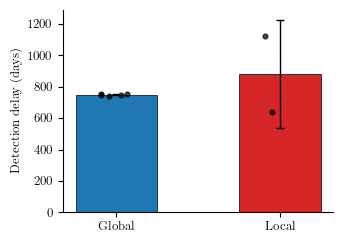

In [24]:
out_dir = Path("out")
conditions = ["global", "local"]
colors = {"global": "tab:blue", "local": "tab:red"}

fig, ax = plt.subplots(figsize=SINGLE_COL)

x = np.arange(len(conditions))
width = 0.5
means = [agg.loc[c, "delay_days_mean"] for c in conditions]
stds = [agg.loc[c, "delay_days_std"] for c in conditions]

ax.bar(x, means, width, yerr=stds, capsize=3,
       color=[colors[c] for c in conditions], edgecolor="black", linewidth=0.5)

for c_idx, c in enumerate(conditions):
    vals = df.loc[df["condition"] == c, "delay_days"].values
    jitter = np.random.default_rng(0).uniform(-0.1, 0.1, size=len(vals))
    ax.scatter(x[c_idx] + jitter, vals, color="black", s=12, zorder=3, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in conditions])
ax.set_ylabel("Detection delay (days)")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(out_dir / "benchmark_detection_delay.pdf")
fig.savefig(out_dir / "benchmark_detection_delay.pgf")
plt.show()

## Validation Metrics

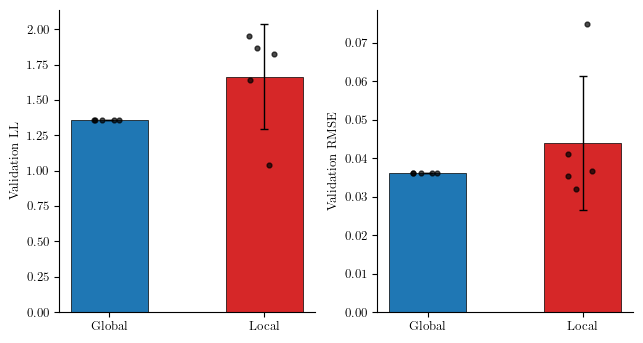

In [25]:
fig, axes = plt.subplots(1, 2, figsize=DOUBLE_COL)

metrics = [
    ("val_ll", "Validation LL"),
    ("val_rmse", "Validation RMSE"),
]

x = np.arange(len(conditions))
width = 0.5
for ax, (metric, label) in zip(axes, metrics):
    means = [agg.loc[c, f"{metric}_mean"] for c in conditions]
    stds = [agg.loc[c, f"{metric}_std"] for c in conditions]

    ax.bar(x, means, width, yerr=stds, capsize=3,
           color=[colors[c] for c in conditions], edgecolor="black", linewidth=0.5)

    for c_idx, c in enumerate(conditions):
        vals = df.loc[df["condition"] == c, metric].values
        jitter = np.random.default_rng(0).uniform(-0.1, 0.1, size=len(vals))
        ax.scatter(x[c_idx] + jitter, vals, color="black", s=12, zorder=3, alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize() for c in conditions])
    ax.set_ylabel(label)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(out_dir / "benchmark_validation_metrics.pdf")
fig.savefig(out_dir / "benchmark_validation_metrics.pgf")
plt.show()

## False Alarm Rate

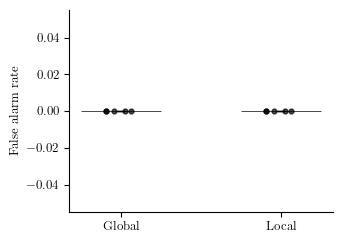

In [26]:
fig, ax = plt.subplots(figsize=SINGLE_COL)

x = np.arange(len(conditions))
width = 0.5
means = [agg.loc[c, "far_mean"] for c in conditions]
stds = [agg.loc[c, "far_std"] for c in conditions]

ax.bar(x, means, width, yerr=stds, capsize=3,
       color=[colors[c] for c in conditions], edgecolor="black", linewidth=0.5)

for c_idx, c in enumerate(conditions):
    vals = df.loc[df["condition"] == c, "false_alarm_rate"].values
    jitter = np.random.default_rng(0).uniform(-0.1, 0.1, size=len(vals))
    ax.scatter(x[c_idx] + jitter, vals, color="black", s=12, zorder=3, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in conditions])
ax.set_ylabel("False alarm rate")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(out_dir / "benchmark_false_alarm_rate.pdf")
fig.savefig(out_dir / "benchmark_false_alarm_rate.pgf")
plt.show()